In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
movies = pd.read_csv(r"C:\Users\ACER\Desktop\Dataset\DATA\Movie\Moive lens\ml-latest-small\ml-latest-small\movies.csv")
tags = pd.read_csv(r"C:\Users\ACER\Desktop\Dataset\DATA\Movie\Moive lens\ml-latest-small\ml-latest-small\tags.csv")
ratings = pd.read_csv(r"C:\Users\ACER\Desktop\Dataset\DATA\Movie\Moive lens\ml-latest-small\ml-latest-small\ratings.csv")

# Thiết lập seaborn
sns.set(style="whitegrid")


In [2]:
print("movies.csv:")
print(movies.info())
print(movies.head(), "\n")



movies.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
None
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy   



In [3]:

print("ratings.csv:")
print(ratings.info())
print(ratings.head(), "\n")

ratings.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931 



In [4]:

print("tags.csv:")
print(tags.info())
print(tags.head(), "\n")


tags.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB
None
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferrell  1445714992
3       2    89774     Boxing story  1445715207
4       2    89774              MMA  1445715200 



In [5]:
tag_counts = tags.groupby("movieId").size()
print("Số phim có tag:", tag_counts.count())
print("Số tag trung bình mỗi phim:", tag_counts.mean())


Số phim có tag: 1572
Số tag trung bình mỗi phim: 2.3428753180661577


In [6]:
print("Tổng số phim:", movies['movieId'].nunique())
print("Tổng số người dùng:", ratings['userId'].nunique())
print("Trung bình số rating mỗi phim:", ratings.groupby('movieId')['rating'].count().mean())


Tổng số phim: 9742
Tổng số người dùng: 610
Trung bình số rating mỗi phim: 10.369806663924312


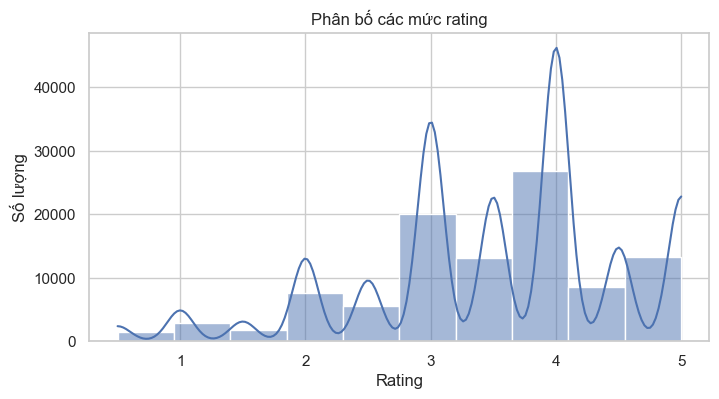

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(ratings['rating'], bins=10, kde=True)
plt.title('Phân bố các mức rating')
plt.xlabel('Rating')
plt.ylabel('Số lượng')
plt.show()


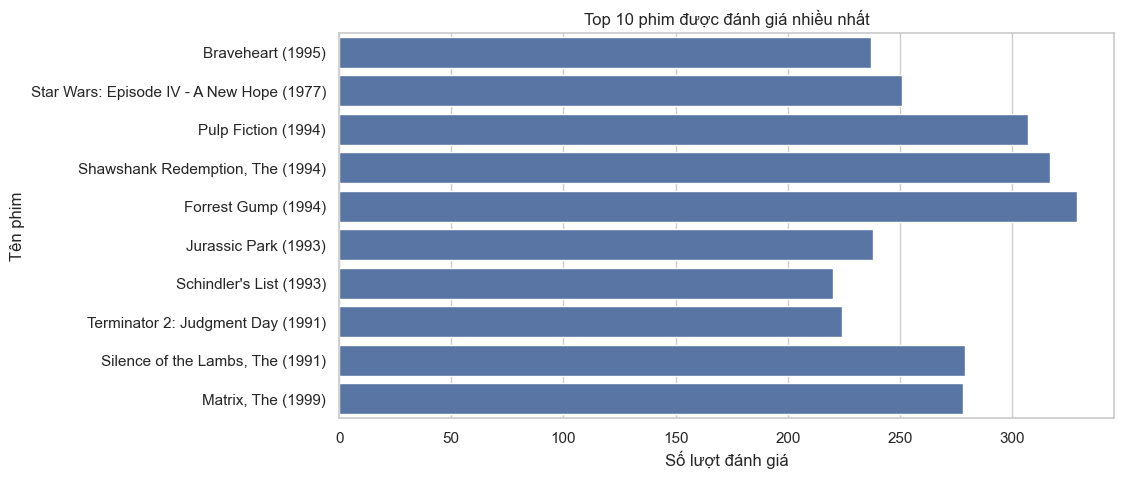

In [8]:
top_rated = ratings['movieId'].value_counts().head(10)
top_movies = movies[movies['movieId'].isin(top_rated.index)]

merged = top_movies.merge(top_rated.rename("num_ratings"), left_on='movieId', right_index=True)
plt.figure(figsize=(10, 5))
sns.barplot(data=merged, x='num_ratings', y='title')
plt.title('Top 10 phim được đánh giá nhiều nhất')
plt.xlabel('Số lượt đánh giá')
plt.ylabel('Tên phim')
plt.show()


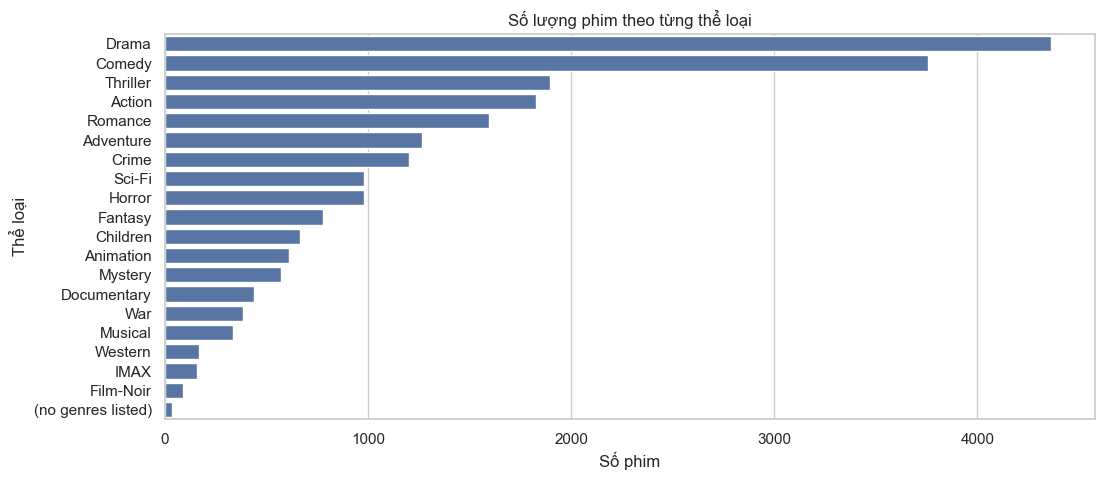

In [9]:
genres_exploded = movies['genres'].str.split('|').explode()
genre_counts = genres_exploded.value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Số lượng phim theo từng thể loại')
plt.xlabel('Số phim')
plt.ylabel('Thể loại')
plt.show()


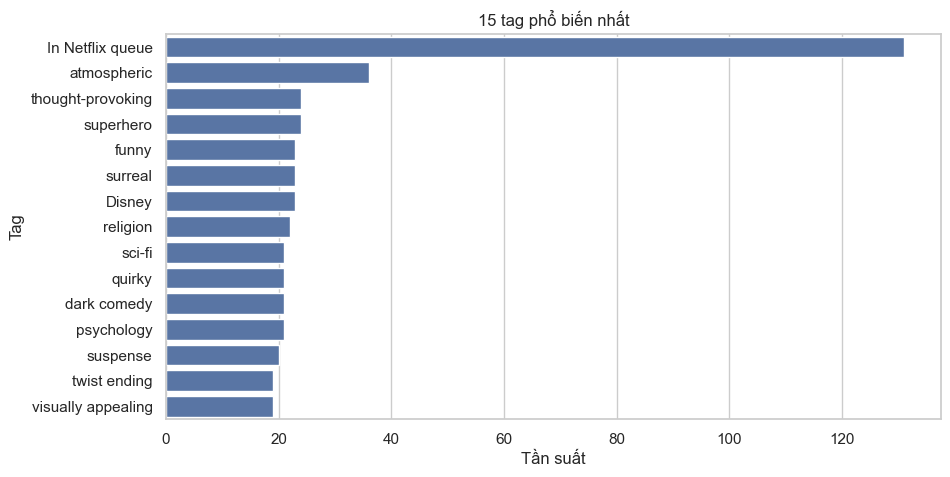

In [10]:
top_tags = tags['tag'].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_tags.values, y=top_tags.index)
plt.title('15 tag phổ biến nhất')
plt.xlabel('Tần suất')
plt.ylabel('Tag')
plt.show()


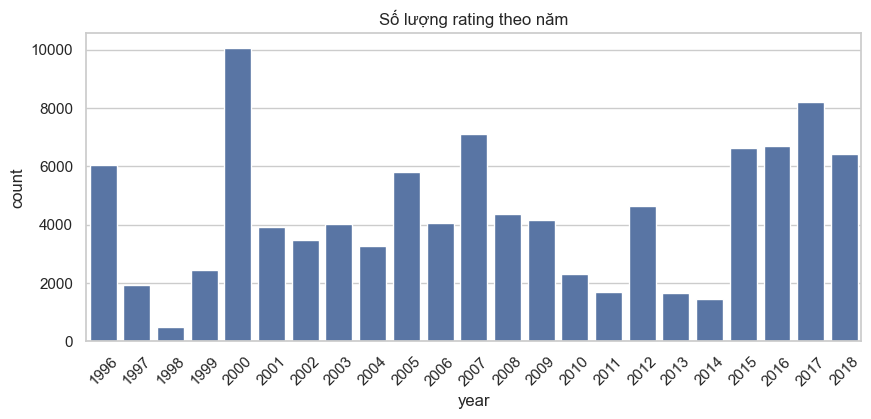

In [11]:
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['timestamp'].dt.year

plt.figure(figsize=(10, 4))
sns.countplot(data=ratings, x='year')
plt.title('Số lượng rating theo năm')
plt.xticks(rotation=45)
plt.show()


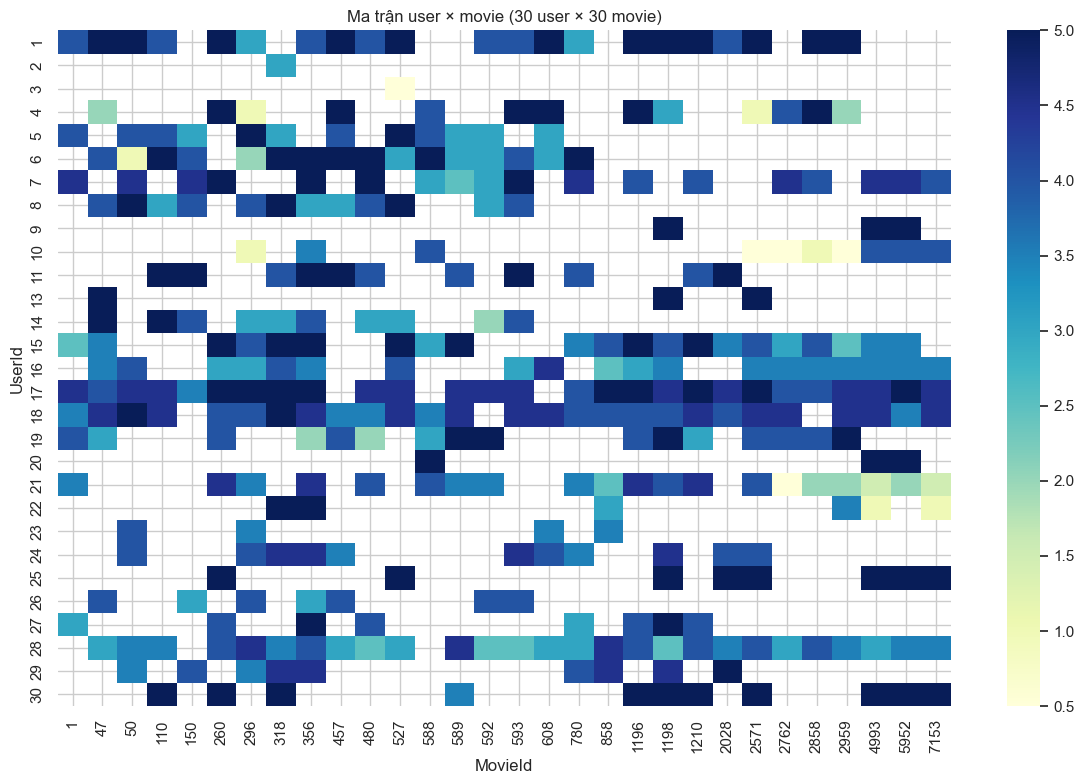

In [12]:
# Chọn ra 30 user đầu tiên
top_users = ratings['userId'].unique()[:30]

# Chọn 30 movie được đánh giá nhiều nhất
top_movies = ratings['movieId'].value_counts().head(30).index

# Lọc dataset ban đầu
filtered_ratings = ratings[
    (ratings['userId'].isin(top_users)) &
    (ratings['movieId'].isin(top_movies))
]

# Pivot ma trận nhỏ
user_movie_matrix = filtered_ratings.pivot(index='userId', columns='movieId', values='rating')

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(user_movie_matrix, annot=False, cmap="YlGnBu", cbar=True)
plt.title("Ma trận user × movie (30 user × 30 movie)")
plt.xlabel("MovieId")
plt.ylabel("UserId")
plt.tight_layout()
plt.show()


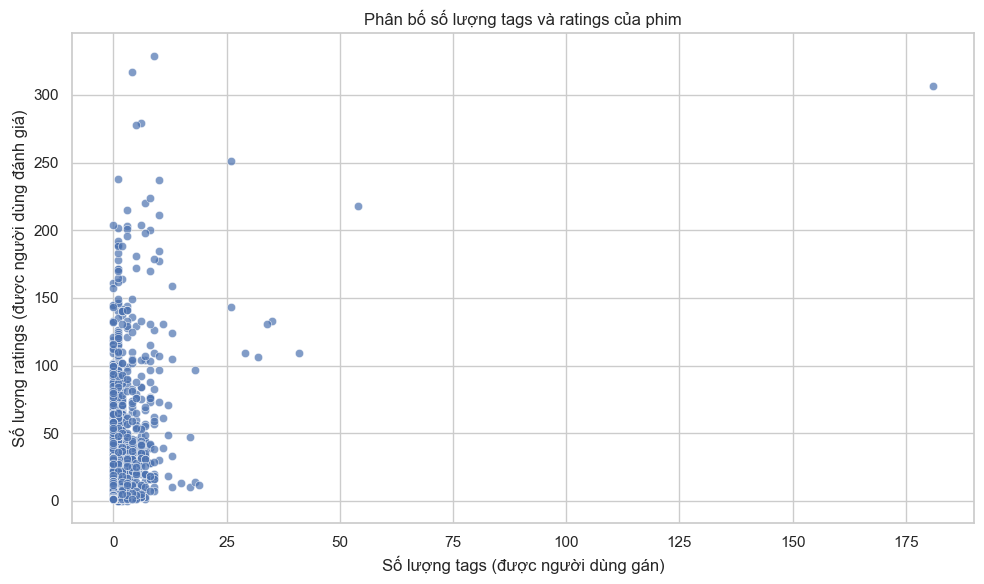

In [13]:
# Tổng hợp số lượng tags và ratings cho mỗi phim
tag_counts = tags.groupby('movieId')['tag'].count().rename("num_tags")
rating_counts = ratings.groupby('movieId')['rating'].count().rename("num_ratings")

# Gộp với thông tin phim
movie_stats = movies.set_index('movieId').join([tag_counts, rating_counts])
movie_stats = movie_stats.fillna(0)  # nếu phim không có tag hoặc rating thì điền 0

# Reset index để vẽ được
movie_stats = movie_stats.reset_index()

# Vẽ scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movie_stats, x='num_tags', y='num_ratings', alpha=0.7)

plt.title('Phân bố số lượng tags và ratings của phim')
plt.xlabel('Số lượng tags (được người dùng gán)')
plt.ylabel('Số lượng ratings (được người dùng đánh giá)')
plt.grid(True)
plt.tight_layout()
plt.show()
